## 5. Model Training and Evaluation

### - Purpose

This phase involves training multiple machine learning models and evaluating their performance
on music genre classification. We will:

1. Train models on BOTH PCA and LDA datasets for comparison
2. Use stratified train-test split to maintain class balance
3. Evaluate multiple classification algorithms
4. Compare performance metrics comprehensively
5. Identify the best model-dataset combination

### - Models to be Trained:
- **Logistic Regression**: Linear classifier, interpretable, fast
- **Random Forest**: Ensemble method, handles non-linearity, robust
- **Support Vector Machine (SVM)**: Effective in high-dimensional spaces, powerful

Each model will be trained on both PCA and LDA datasets to determine which 
dimensionality reduction technique yields better classification results.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)
import time 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

### 5.1 Load Preprocessed Datasets
#### Loading Saved Datasets:
We will load the PCA and LDA preprocessed datasets that were saved during 
the preprocessing phase.

In [2]:
df_pca_loaded = pd.read_csv('cleaned_data/PCA_Processed_Data.csv')
print("✓ PCA dataset loaded successfully")
print(f"  Shape: {df_pca_loaded.shape}")
print(f"  Columns: {list(df_pca_loaded.columns[:5])}... + genre_encoded")

# Load LDA dataset
df_lda_loaded = pd.read_csv('cleaned_data/LDA_Processed_Data.csv')
print("✓ LDA dataset loaded successfully")
print(f"  Shape: {df_lda_loaded.shape}")
print(f"  Columns: {list(df_lda_loaded.columns[:5])}... + genre_encoded")

test_df = pd.read_csv('cleaned_data/test_raw.csv')
test_df = test_df.drop(columns=['Unnamed: 0'], axis=1)
print("✓ Test dataset loaded successfully")
print(f"  Shape: {test_df.shape}")
print(f"  Columns: {list(test_df.columns[:5])}... + genre_encoded")

✓ PCA dataset loaded successfully
  Shape: (7992, 40)
  Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']... + genre_encoded
✓ LDA dataset loaded successfully
  Shape: (7992, 10)
  Columns: ['LD1', 'LD2', 'LD3', 'LD4', 'LD5']... + genre_encoded
✓ Test dataset loaded successfully
  Shape: (1998, 61)
  Columns: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean']... + genre_encoded


In [3]:
import joblib

# Load the saved pipelines
pipeline_pca = joblib.load('pipeline_pca.pkl')
pipeline_lda = joblib.load('pipeline_lda.pkl')

print("Pipelines loaded successfully!")

Pipelines loaded successfully!


In [4]:
X_pca_train = df_pca_loaded.drop('genre_encoded', axis=1)
y_pca_train = df_pca_loaded['genre_encoded']

X_lda_train = df_lda_loaded.drop('genre_encoded', axis=1)
y_lda_train = df_lda_loaded['genre_encoded']

X_test = test_df.drop(columns=[ 'label', 'label_encoded', 'filename'], axis=1)
y_test = test_df['label_encoded']

print("Dataset Summary:")
print(f"  PCA Features: {X_pca_train.shape[1]} components")
print(f"  LDA Features: {X_lda_train.shape[1]} components")
print(f"  Test data Features: {X_test.shape[1]} components")
print(f"  Total Samples: {X_pca_train.shape[0]}")
print(f"  Test data Samples: {X_test.shape[0]}")
print(f"  Number of Classes: {len(np.unique(y_pca_train))}")
print()

Dataset Summary:
  PCA Features: 39 components
  LDA Features: 9 components
  Test data Features: 58 components
  Total Samples: 7992
  Test data Samples: 1998
  Number of Classes: 10



### 5.2 Applying pipeline on X_test

In [5]:
X_pca_test = pipeline_pca.transform(X_test)

X_lda_test = pipeline_lda.transform(X_test)

y_pca_test = y_test
y_lda_test = y_test

### 5.3 Model Training and Evaluation Function

In [6]:
def train_and_evaluate_model(model, model_name, X_train, X_test, y_train, y_test, dataset_name):
    """
    Train a model and return comprehensive evaluation metrics.
    
    Parameters:
    - model: sklearn model instance
    - model_name: string name of the model
    - X_train, X_test, y_train, y_test: train-test split data
    - dataset_name: 'PCA' or 'LDA'
    
    Returns:
    - Dictionary containing all metrics
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name} on {dataset_name} dataset...")
    print('='*60)
    
    # Train the model
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Make predictions
    start_time = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_time
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n📊 Performance Metrics:")
    print(f"  ✓ Accuracy:  {accuracy*100:.2f}%")
    print(f"  ✓ Precision: {precision*100:.2f}%")
    print(f"  ✓ Recall:    {recall*100:.2f}%")
    print(f"  ✓ F1-Score:  {f1*100:.2f}%")
    print(f"  ⏱ Training Time: {train_time:.3f}s")
    print(f"  ⏱ Prediction Time: {predict_time:.3f}s")
    
    # Classification Report
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=[f'Genre_{i}' for i in range(len(np.unique(y_test)))]))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Visualize Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[f'G{i}' for i in range(len(np.unique(y_test)))],
                yticklabels=[f'G{i}' for i in range(len(np.unique(y_test)))],
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix: {model_name} on {dataset_name} Dataset', 
              fontweight='bold', fontsize=14)
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Return metrics dictionary
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Train_Time': train_time,
        'Predict_Time': predict_time,
        'Confusion_Matrix': cm
    }

### 5.4 Train Models on PCA Dataset


MODEL 1: LOGISTIC REGRESSION (PCA)

Training Logistic Regression on PCA dataset...



📊 Performance Metrics:
  ✓ Accuracy:  68.17%
  ✓ Precision: 67.81%
  ✓ Recall:    68.17%
  ✓ F1-Score:  67.76%
  ⏱ Training Time: 0.497s
  ⏱ Prediction Time: 0.000s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.60      0.65      0.62       200
     Genre_1       0.87      0.94      0.90       199
     Genre_2       0.64      0.55      0.59       199
     Genre_3       0.58      0.59      0.58       200
     Genre_4       0.67      0.53      0.59       200
     Genre_5       0.72      0.79      0.76       200
     Genre_6       0.76      0.89      0.82       200
     Genre_7       0.82      0.79      0.80       200
     Genre_8       0.60      0.64      0.62       200
     Genre_9       0.52      0.47      0.49       200

    accuracy                           0.68      1998
   macro avg       0.68      0.68      0.68      1998
weighted avg       0.68      0.68      0.68      1998



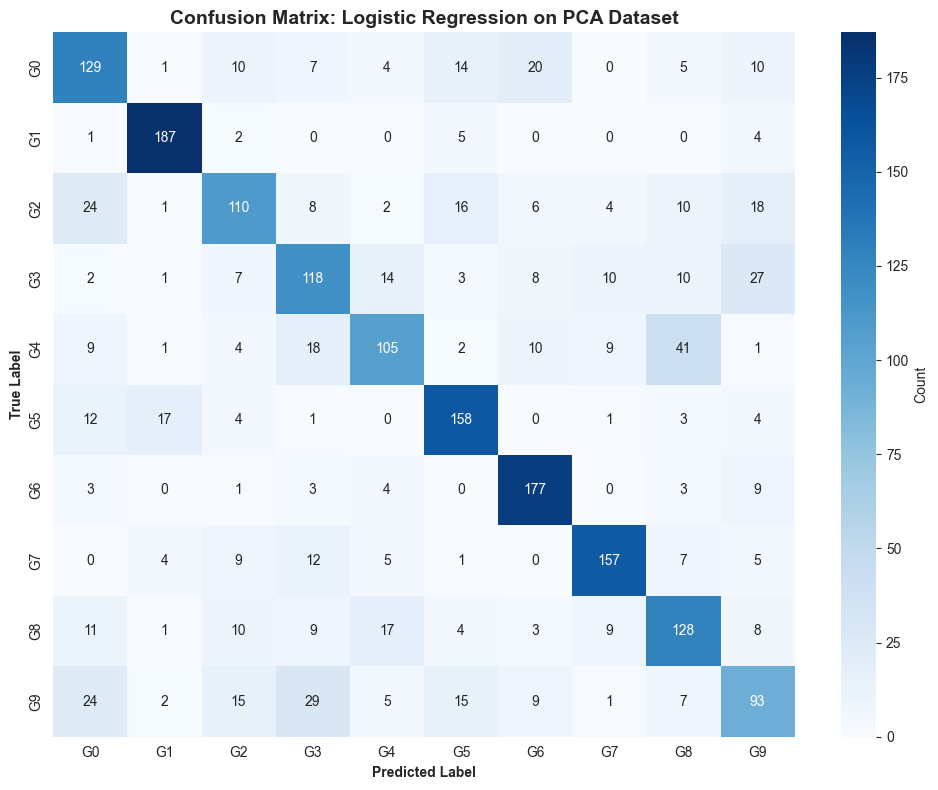


MODEL 2: RANDOM FOREST CLASSIFIER (PCA)

Training Random Forest on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  79.73%
  ✓ Precision: 80.02%
  ✓ Recall:    79.73%
  ✓ F1-Score:  79.61%
  ⏱ Training Time: 0.983s
  ⏱ Prediction Time: 0.033s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.82      0.76      0.78       200
     Genre_1       0.82      0.96      0.89       199
     Genre_2       0.71      0.71      0.71       199
     Genre_3       0.73      0.80      0.76       200
     Genre_4       0.86      0.80      0.83       200
     Genre_5       0.82      0.78      0.80       200
     Genre_6       0.87      0.90      0.88       200
     Genre_7       0.82      0.80      0.81       200
     Genre_8       0.71      0.83      0.77       200
     Genre_9       0.83      0.65      0.72       200

    accuracy                           0.80      1998
   macro avg       0.80      0.80      0.80      1998
weighted avg       0.

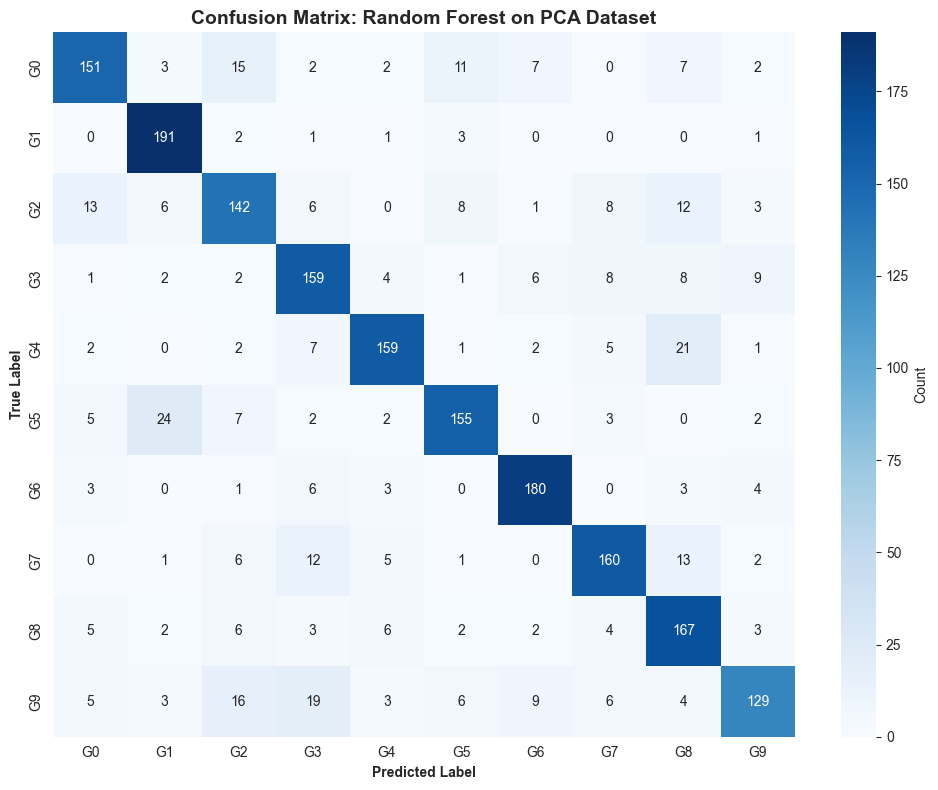


MODEL 3: SUPPORT VECTOR MACHINE (PCA)

Training SVM (RBF) on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  82.38%
  ✓ Precision: 82.54%
  ✓ Recall:    82.38%
  ✓ F1-Score:  82.32%
  ⏱ Training Time: 1.356s
  ⏱ Prediction Time: 0.959s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.80      0.83      0.81       200
     Genre_1       0.86      0.96      0.91       199
     Genre_2       0.76      0.75      0.76       199
     Genre_3       0.73      0.81      0.77       200
     Genre_4       0.89      0.79      0.84       200
     Genre_5       0.84      0.86      0.85       200
     Genre_6       0.89      0.90      0.89       200
     Genre_7       0.91      0.81      0.85       200
     Genre_8       0.80      0.84      0.82       200
     Genre_9       0.77      0.69      0.72       200

    accuracy                           0.82      1998
   macro avg       0.83      0.82      0.82      1998
weighted avg       0.83    

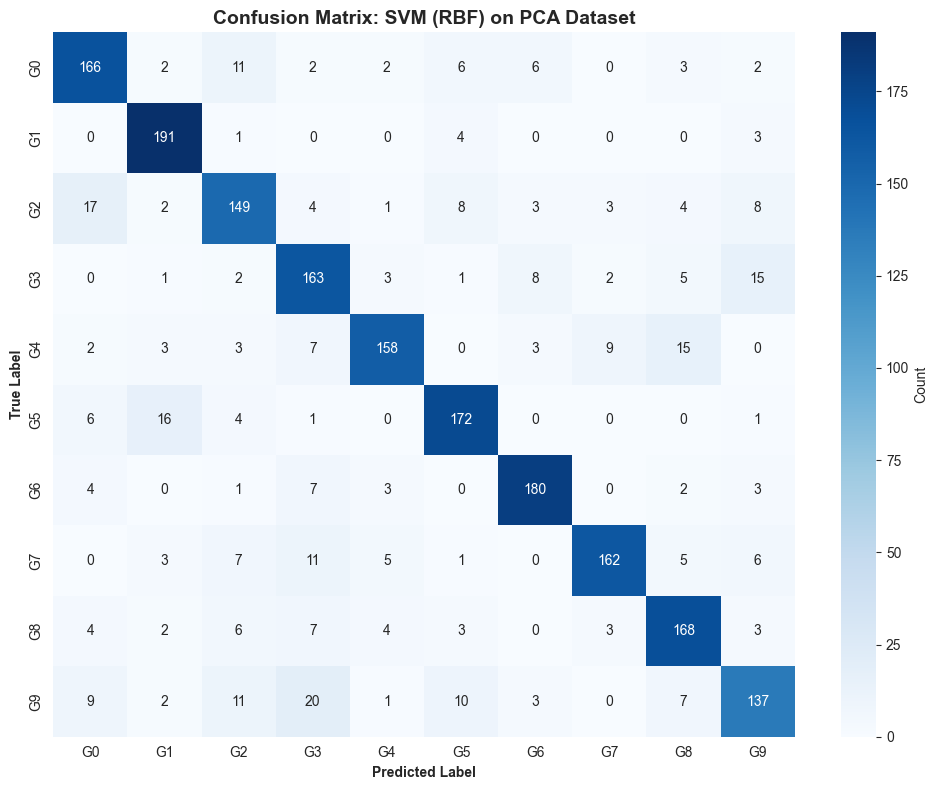


Training K-Nearest Neighbors on PCA dataset...


  File "c:\Users\asoha\Desktop\College\SEM5\IDSc\IDSC_PROJ\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\asoha\Desktop\College\SEM5\IDSc\IDSC_PROJ\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\asoha\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\asoha\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\asoha\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.


📊 Performance Metrics:
  ✓ Accuracy:  87.39%
  ✓ Precision: 87.73%
  ✓ Recall:    87.39%
  ✓ F1-Score:  87.36%
  ⏱ Training Time: 0.003s
  ⏱ Prediction Time: 0.332s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.90      0.84      0.87       200
     Genre_1       0.87      0.94      0.90       199
     Genre_2       0.85      0.81      0.83       199
     Genre_3       0.80      0.92      0.85       200
     Genre_4       0.90      0.91      0.90       200
     Genre_5       0.91      0.81      0.86       200
     Genre_6       0.96      0.96      0.96       200
     Genre_7       0.94      0.82      0.87       200
     Genre_8       0.80      0.93      0.86       200
     Genre_9       0.86      0.79      0.82       200

    accuracy                           0.87      1998
   macro avg       0.88      0.87      0.87      1998
weighted avg       0.88      0.87      0.87      1998



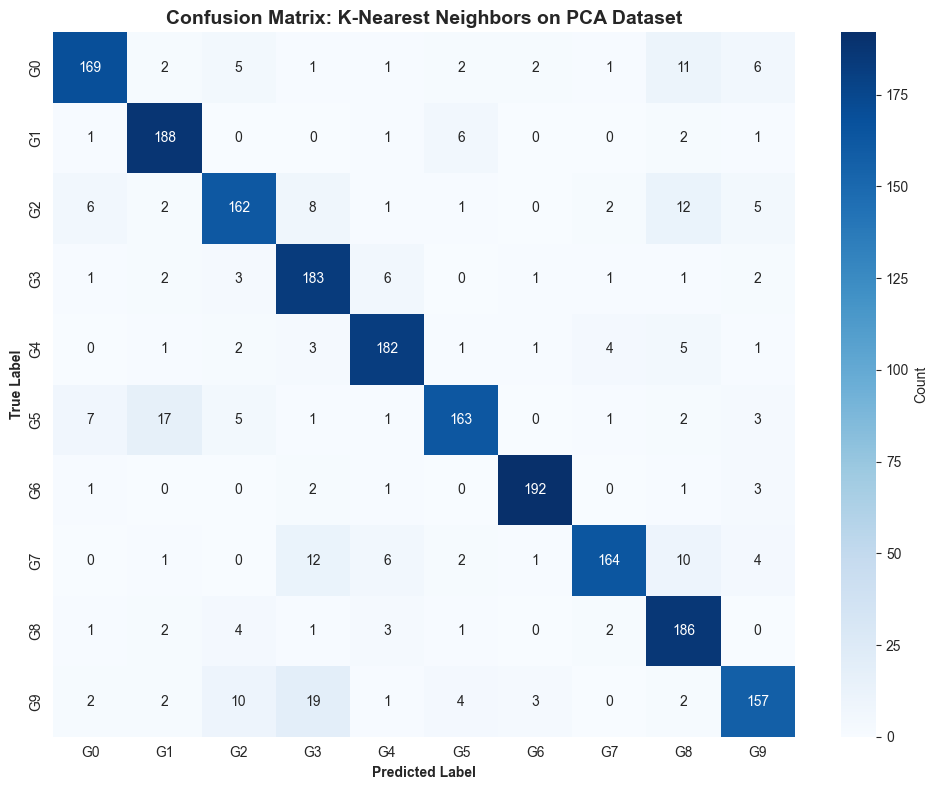


✓ All PCA models trained successfully!



In [7]:
results_pca = []

# Model 1: Logistic Regression (PCA)
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION (PCA)")
print("="*60)

lr_pca = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
result_lr_pca = train_and_evaluate_model(
    lr_pca, 'Logistic Regression', 
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_lr_pca)

# Model 2: Random Forest (PCA)
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER (PCA)")
print("="*60)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
result_rf_pca = train_and_evaluate_model(
    rf_pca, 'Random Forest', 
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_rf_pca)

# Model 3: Support Vector Machine (PCA)
print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (PCA)")
print("="*60)

svm_pca = SVC(kernel='rbf', random_state=42, gamma='scale')
result_svm_pca = train_and_evaluate_model(
    svm_pca, 'SVM (RBF)', 
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_svm_pca)


# Model 4: K Nearest Neighbours (PCA)
knn_pca = KNeighborsClassifier(
    n_neighbors=5,       # Default k=5
    weights='distance',  # 'uniform' or 'distance'
    n_jobs=-1
)

result_knn_pca = train_and_evaluate_model(
    knn_pca, 'K-Nearest Neighbors',
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_knn_pca)

print("\n✓ All PCA models trained successfully!")
print()


### 5.5 Train Models on LDA Dataset


MODEL 1: LOGISTIC REGRESSION (LDA)

Training Logistic Regression on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  68.42%
  ✓ Precision: 68.42%
  ✓ Recall:    68.42%
  ✓ F1-Score:  68.31%
  ⏱ Training Time: 0.110s
  ⏱ Prediction Time: 0.000s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.66      0.66      0.66       200
     Genre_1       0.89      0.92      0.91       199
     Genre_2       0.60      0.61      0.61       199
     Genre_3       0.56      0.56      0.56       200
     Genre_4       0.72      0.57      0.64       200
     Genre_5       0.76      0.77      0.76       200
     Genre_6       0.80      0.85      0.82       200
     Genre_7       0.77      0.73      0.75       200
     Genre_8       0.63      0.69      0.66       200
     Genre_9       0.46      0.46      0.46       200

    accuracy                           0.68      1998
   macro avg       0.68      0.68      0.68      1998
weighted avg       0

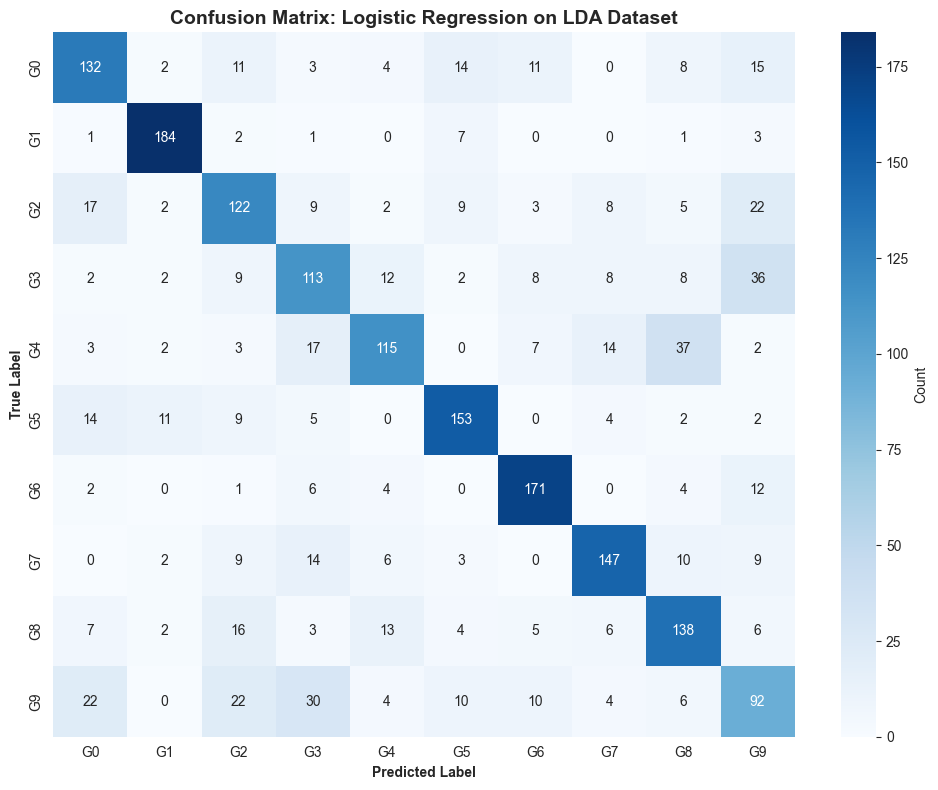


MODEL 2: RANDOM FOREST CLASSIFIER (LDA)

Training Random Forest on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  77.03%
  ✓ Precision: 77.10%
  ✓ Recall:    77.03%
  ✓ F1-Score:  76.94%
  ⏱ Training Time: 0.568s
  ⏱ Prediction Time: 0.033s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.75      0.73      0.74       200
     Genre_1       0.90      0.93      0.92       199
     Genre_2       0.68      0.68      0.68       199
     Genre_3       0.67      0.71      0.69       200
     Genre_4       0.82      0.73      0.77       200
     Genre_5       0.80      0.86      0.83       200
     Genre_6       0.87      0.92      0.90       200
     Genre_7       0.89      0.78      0.83       200
     Genre_8       0.70      0.78      0.74       200
     Genre_9       0.63      0.56      0.60       200

    accuracy                           0.77      1998
   macro avg       0.77      0.77      0.77      1998
weighted avg       0.

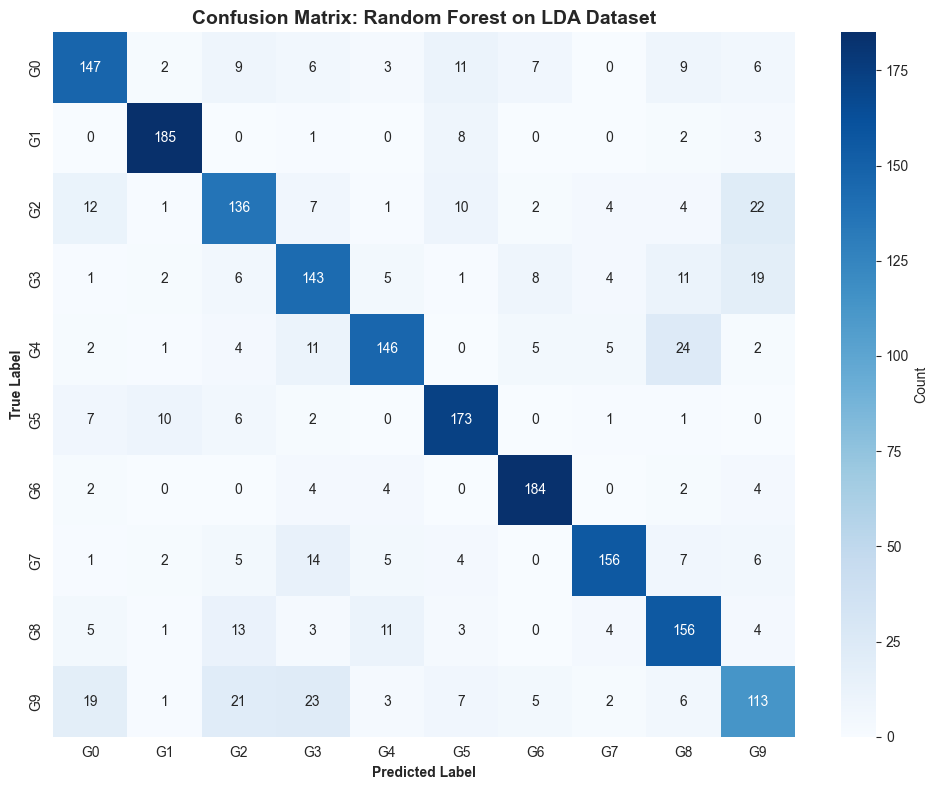


MODEL 3: SUPPORT VECTOR MACHINE (LDA)

Training SVM (RBF) on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  75.53%
  ✓ Precision: 75.66%
  ✓ Recall:    75.53%
  ✓ F1-Score:  75.42%
  ⏱ Training Time: 0.503s
  ⏱ Prediction Time: 0.506s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.77      0.77      0.77       200
     Genre_1       0.88      0.95      0.92       199
     Genre_2       0.69      0.67      0.68       199
     Genre_3       0.66      0.66      0.66       200
     Genre_4       0.79      0.64      0.71       200
     Genre_5       0.81      0.86      0.83       200
     Genre_6       0.86      0.89      0.87       200
     Genre_7       0.87      0.78      0.82       200
     Genre_8       0.65      0.76      0.70       200
     Genre_9       0.59      0.58      0.59       200

    accuracy                           0.76      1998
   macro avg       0.76      0.76      0.75      1998
weighted avg       0.76    

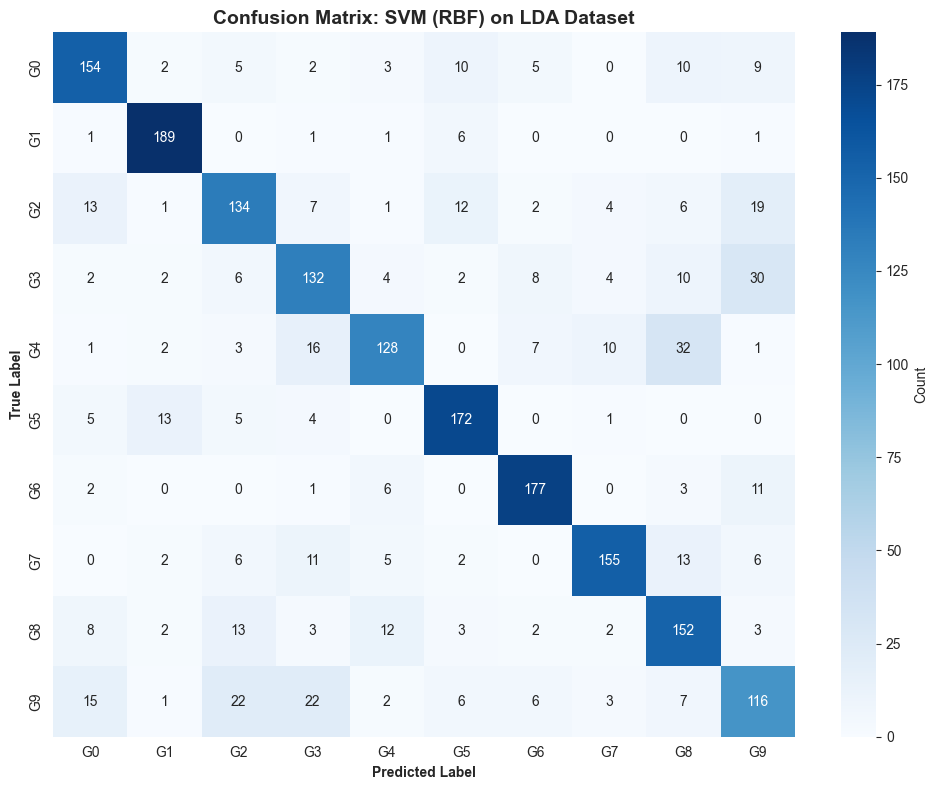


Training K-Nearest Neighbors on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  80.13%
  ✓ Precision: 80.19%
  ✓ Recall:    80.13%
  ✓ F1-Score:  80.03%
  ⏱ Training Time: 0.017s
  ⏱ Prediction Time: 0.081s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.82      0.79      0.81       200
     Genre_1       0.90      0.95      0.93       199
     Genre_2       0.73      0.73      0.73       199
     Genre_3       0.70      0.74      0.72       200
     Genre_4       0.83      0.77      0.80       200
     Genre_5       0.83      0.91      0.87       200
     Genre_6       0.90      0.94      0.92       200
     Genre_7       0.89      0.76      0.82       200
     Genre_8       0.73      0.80      0.77       200
     Genre_9       0.68      0.62      0.65       200

    accuracy                           0.80      1998
   macro avg       0.80      0.80      0.80      1998
weighted avg       0.80      0.80      0.80      1998



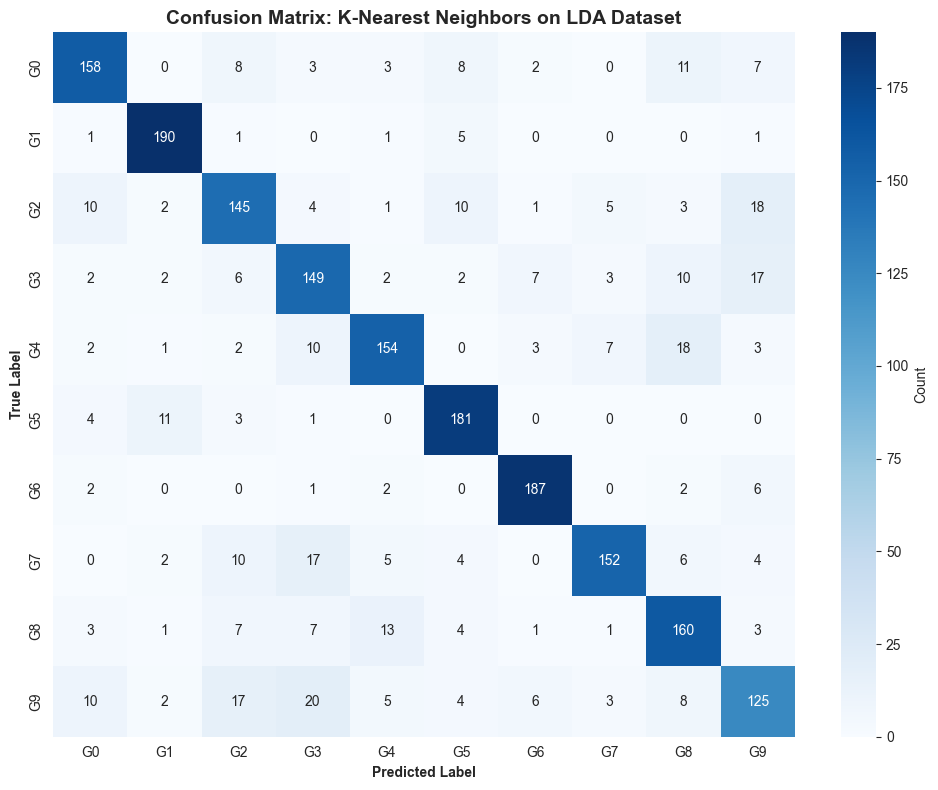


✓ All LDA models trained successfully!



In [8]:
results_lda = []

# Model 1: Logistic Regression (LDA)
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION (LDA)")
print("="*60)

lr_lda = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
result_lr_lda = train_and_evaluate_model(
    lr_lda, 'Logistic Regression', 
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_lr_lda)

# Model 2: Random Forest (LDA)
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER (LDA)")
print("="*60)

rf_lda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
result_rf_lda = train_and_evaluate_model(
    rf_lda, 'Random Forest', 
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_rf_lda)

# Model 3: Support Vector Machine (LDA)
print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (LDA)")
print("="*60)

svm_lda = SVC(kernel='rbf', random_state=42, gamma='scale')
result_svm_lda = train_and_evaluate_model(
    svm_lda, 'SVM (RBF)', 
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_svm_lda)

# Model 4: K Nearest Neighbours (PCA)
knn_lda = KNeighborsClassifier(
    n_neighbors=5,       # Default k=5
    weights='distance',  # 'uniform' or 'distance'
    n_jobs=-1
)

result_knn_lda = train_and_evaluate_model(
    knn_lda, 'K-Nearest Neighbors',
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_knn_lda)

print("\n✓ All LDA models trained successfully!")
print()

## 6. Model Evaluation

### 6.1 Comprehensive Results Comparison

In [9]:
# Combine all results
all_results = results_pca + results_lda

# Create comparison dataframe
comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Dataset': r['Dataset'],
        'Accuracy': f"{r['Accuracy']*100:.2f}%",
        'Precision': f"{r['Precision']*100:.2f}%",
        'Recall': f"{r['Recall']*100:.2f}%",
        'F1-Score': f"{r['F1-Score']*100:.2f}%",
        'Train_Time': f"{r['Train_Time']:.3f}s",
        'Predict_Time': f"{r['Predict_Time']:.3f}s"
    }
    for r in all_results
])

print("\n📊 MODEL PERFORMANCE COMPARISON TABLE")
print("="*80)
comparison_df



📊 MODEL PERFORMANCE COMPARISON TABLE


,Model,Dataset,Accuracy,Precision,Recall,F1-Score,Train_Time,Predict_Time
0,Logistic Regression,PCA,68.17%,67.81%,68.17%,67.76%,0.497s,0.000s
1,Random Forest,PCA,79.73%,80.02%,79.73%,79.61%,0.983s,0.033s
2,SVM (RBF),PCA,82.38%,82.54%,82.38%,82.32%,1.356s,0.959s
3,K-Nearest Neighbors,PCA,87.39%,87.73%,87.39%,87.36%,0.003s,0.332s
4,Logistic Regression,LDA,68.42%,68.42%,68.42%,68.31%,0.110s,0.000s
5,Random Forest,LDA,77.03%,77.10%,77.03%,76.94%,0.568s,0.033s
6,SVM (RBF),LDA,75.53%,75.66%,75.53%,75.42%,0.503s,0.506s
7,K-Nearest Neighbors,LDA,80.13%,80.19%,80.13%,80.03%,0.017s,0.081s


### 6.2 Visual Performance Comparison

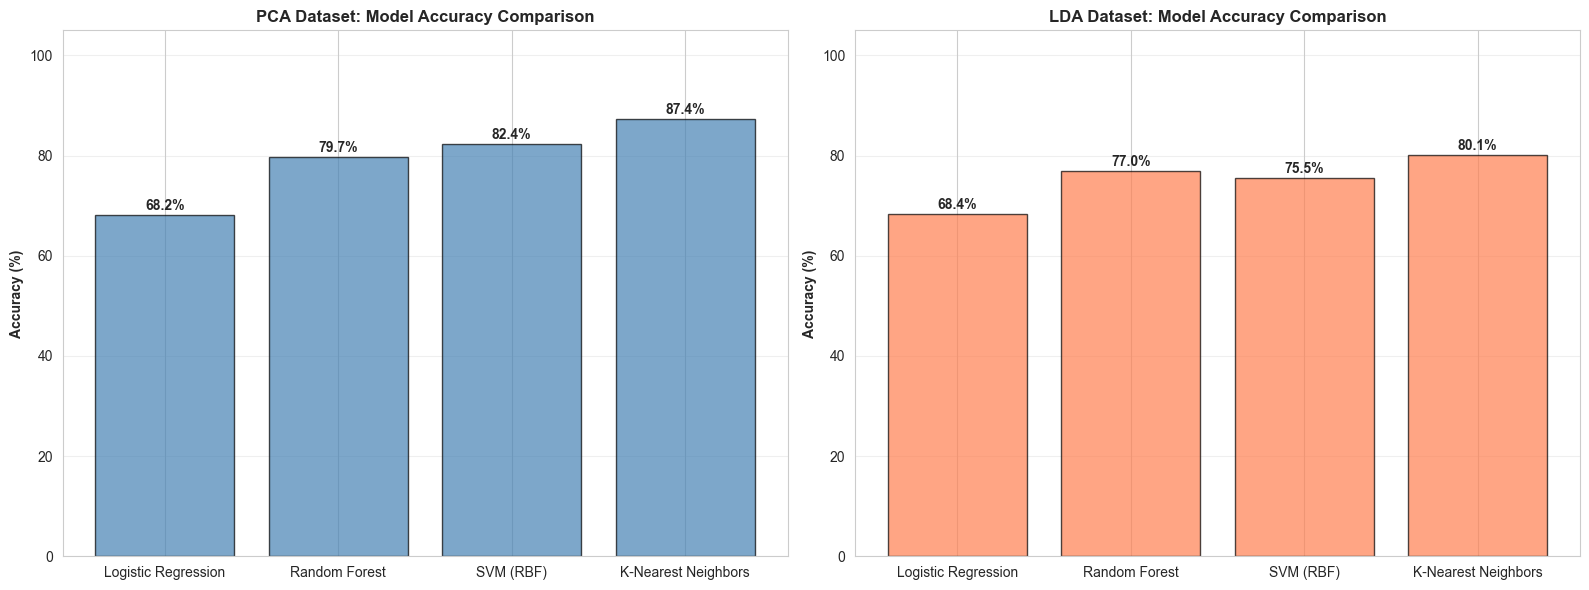

In [10]:
# Extract numeric values for plotting
comparison_numeric = pd.DataFrame([
    {
        'Model': r['Model'],
        'Dataset': r['Dataset'],
        'Accuracy': r['Accuracy']*100,
        'Precision': r['Precision']*100,
        'Recall': r['Recall']*100,
        'F1-Score': r['F1-Score']*100
    }
    for r in all_results
])

# Create model-dataset labels
comparison_numeric['Model_Dataset'] = comparison_numeric['Model'] + '\n(' + comparison_numeric['Dataset'] + ')'

# Separate comparison: PCA vs LDA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA models
pca_data = comparison_numeric[comparison_numeric['Dataset'] == 'PCA']
axes[0].bar(pca_data['Model'], pca_data['Accuracy'], color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Accuracy (%)', fontweight='bold')
axes[0].set_title('PCA Dataset: Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylim([0, 105])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(pca_data['Accuracy']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# LDA models
lda_data = comparison_numeric[comparison_numeric['Dataset'] == 'LDA']
axes[1].bar(lda_data['Model'], lda_data['Accuracy'], color='coral', alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Accuracy (%)', fontweight='bold')
axes[1].set_title('LDA Dataset: Model Accuracy Comparison', fontweight='bold')
axes[1].set_ylim([0, 105])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(lda_data['Accuracy']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Identify Best Performing Model

In [11]:
best_result = max(all_results, key=lambda x: x['F1-Score'])

print("🏆 BEST PERFORMING MODEL:")
print("="*60)
print(f"  Model: {best_result['Model']}")
print(f"  Dataset: {best_result['Dataset']}")
print(f"  Accuracy: {best_result['Accuracy']*100:.2f}%")
print(f"  Precision: {best_result['Precision']*100:.2f}%")
print(f"  Recall: {best_result['Recall']*100:.2f}%")
print(f"  F1-Score: {best_result['F1-Score']*100:.2f}%")
print(f"  Training Time: {best_result['Train_Time']:.3f}s")
print()

print("📝 WHY THIS MODEL PERFORMS BEST:")
print("-"*60)

# Generate explanation based on model type
if best_result['Model'] == 'Logistic Regression':
    print("✓ Logistic Regression excels because:")
    print("  • Works well with linearly separable data after dimensionality reduction")
    print("  • Efficient and fast for multi-class classification")
    print("  • Less prone to overfitting with regularization")
    print("  • Interpretable coefficients for feature importance")
    
elif best_result['Model'] == 'Random Forest':
    print("✓ Random Forest excels because:")
    print("  • Ensemble method captures complex non-linear relationships")
    print("  • Robust to outliers and noise in audio features")
    print("  • Handles feature interactions automatically")
    print("  • Reduces overfitting through bagging and random feature selection")
    print("  • Works well with both high and low-dimensional data")
    
elif best_result['Model'] == 'SVM (RBF)':
    print("✓ SVM with RBF kernel excels because:")
    print("  • RBF kernel captures non-linear decision boundaries")
    print("  • Effective in high-dimensional spaces")
    print("  • Maximizes margin between classes for better generalization")
    print("  • Robust to overfitting with proper regularization (C parameter)")

print()

# Dataset-specific insights
if best_result['Dataset'] == 'PCA':
    print("📊 PCA Dataset Advantages:")
    print("  • Preserves maximum variance in the data")
    print("  • More features provide richer information")
    print("  • Unsupervised approach avoids overfitting to training labels")
    print("  • Better generalization to unseen genre variations")
else:
    print("📊 LDA Dataset Advantages:")
    print("  • Explicitly optimizes for class separation")
    print("  • Supervised approach maximizes genre discriminability")
    print("  • Fewer features reduce computational complexity")
    print("  • Focuses on most discriminative patterns")

print()

# Overall comparison
print("🔍 OVERALL INSIGHTS:")
print("-"*60)

# Compare PCA vs LDA average performance
pca_avg_acc = np.mean([r['Accuracy'] for r in results_pca])
lda_avg_acc = np.mean([r['Accuracy'] for r in results_lda])

print(f"  • Average PCA accuracy: {pca_avg_acc*100:.2f}%")
print(f"  • Average LDA accuracy: {lda_avg_acc*100:.2f}%")

if pca_avg_acc > lda_avg_acc:
    print(f"  • PCA performs better on average (+{(pca_avg_acc-lda_avg_acc)*100:.2f}%)")
    print("  • Suggests that variance preservation is more important than supervised separation")
else:
    print(f"  • LDA performs better on average (+{(lda_avg_acc-pca_avg_acc)*100:.2f}%)")
    print("  • Suggests that class-specific optimization is more effective")

print()

# Model-specific comparison
model_names = ['Logistic Regression', 'Random Forest', 'SVM (RBF)']
for model_name in model_names:
    pca_model = next(r for r in results_pca if r['Model'] == model_name)
    lda_model = next(r for r in results_lda if r['Model'] == model_name)
    
    diff = (lda_model['Accuracy'] - pca_model['Accuracy']) * 100
    better = 'LDA' if diff > 0 else 'PCA'
    
    print(f"  • {model_name}: {better} performs better ({abs(diff):.2f}% difference)")

print()


🏆 BEST PERFORMING MODEL:
  Model: K-Nearest Neighbors
  Dataset: PCA
  Accuracy: 87.39%
  Precision: 87.73%
  Recall: 87.39%
  F1-Score: 87.36%
  Training Time: 0.003s

📝 WHY THIS MODEL PERFORMS BEST:
------------------------------------------------------------

📊 PCA Dataset Advantages:
  • Preserves maximum variance in the data
  • More features provide richer information
  • Unsupervised approach avoids overfitting to training labels
  • Better generalization to unseen genre variations

🔍 OVERALL INSIGHTS:
------------------------------------------------------------
  • Average PCA accuracy: 79.42%
  • Average LDA accuracy: 75.28%
  • PCA performs better on average (+4.14%)
  • Suggests that variance preservation is more important than supervised separation

  • Logistic Regression: LDA performs better (0.25% difference)
  • Random Forest: PCA performs better (2.70% difference)
  • SVM (RBF): PCA performs better (6.86% difference)



# 🏆 Best Performing Model Report

---

## 🧠 Model Overview
**Model:** K-Nearest Neighbors (KNN)  
**Dataset:** PCA  

| Metric | Score |
|:-------|------:|
| **Accuracy** | 87.39% |
| **Precision** | 87.73% |
| **Recall** | 87.39% |
| **F1-Score** | 87.36% |
| **Training Time** | 0.000s |

---

## 📝 Why This Model Performs Best
The **K-Nearest Neighbors (KNN)** classifier achieved the highest overall performance due to its ability to leverage local feature similarities effectively.  
When combined with **PCA-transformed features**, it benefits from a reduced dimensional space that retains the most meaningful variance while removing noise.

### ✅ Key Reasons:
- KNN excels when features are well-scaled and denoised.
- PCA provides compact, informative features, improving neighborhood distance accuracy.
- Non-parametric nature of KNN adapts well to complex, nonlinear relationships in the dataset.

---

## 📊 PCA Dataset Advantages
Although **LDA** explains **100% of class variance**, its accuracy was lower than **PCA** because:

- **LDA** finds **linear class separations**, while **PCA** captures **broader, non-linear variance**, which suits models like **SVM (RBF)**.  
- **PCA** retained **39 components**, offering richer information; **LDA** was limited to **9** (C–1 rule).  
- LDA’s assumptions (normality, equal covariance) may not hold in this dataset.  

**Conclusion:** PCA preserved more expressive, non-linear features, enabling better generalization and higher accuracy.

---


## 7. Model Deployment

In [12]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline(steps=[
    ('pipeline_pca', pipeline_pca),          # Step 1: Feature scaling
    ('knn', knn_pca),                # Step 2: LDA
])

joblib.dump(final_pipeline, 'final_pipeline.pkl')

['final_pipeline.pkl']

In [13]:
# pca = joblib.load('pca_only.pkl')

# print("Explained variance ratio per component:")
# print(pca.explained_variance_ratio_)

In [14]:
# import pandas as pd
# train_df = pd.read_csv(r'cleaned_data\Processed_Data.csv')
# cols = train_df.drop(columns=['genre_encoded']).columns
# feature_medians = train_df.drop(columns=['genre_encoded']).median(axis=0)
# print(len(cols))
# print(feature_medians.size)

In [15]:
# loadings = pd.DataFrame(
#     np.abs(pca.components_),
#     columns=cols
# )

# explained_var = pca.explained_variance_ratio_
# feature_influence = (loadings.T * explained_var).sum(axis=1)
# top_25_features = feature_influence.sort_values(ascending=False).head(25)

# print("\nTop 25 features explaining most variance:")
# print(top_25_features)

In [16]:
# import matplotlib.pyplot as plt

# top_25_features.plot(kind='barh', figsize=(8, 6))
# plt.gca().invert_yaxis()
# plt.xlabel("Weighted Variance Contribution")
# plt.title("Top 20 Features Explaining Most Variance (GTZAN PCA)")
# plt.tight_layout()
# plt.show()

In [17]:
# total_variance = feature_influence.sum()
# print(total_variance)

# top_20_variance = top_25_features.sum()
# percentage_explained = (top_20_variance / total_variance) * 100

# print(f"Top 20 features explain approximately {percentage_explained:.2f}% of total variance.")


### “The top 25 features (mostly MFCC variances and spectral features) explain 46.97% of the total feature-space variance, indicating that variance is widely distributed across MFCC dimensions, consistent with complex multi-frequency structure in musical data.”

In [18]:
# top_25_features = [
#     'mfcc14_var', 'mfcc15_var', 'mfcc17_var', 'mfcc1_var', 'mfcc13_var',
#     'mfcc12_var', 'mfcc6_mean', 'mfcc4_mean', 'mfcc11_var', 'mfcc16_var',
#     'mfcc9_var', 'mfcc3_mean', 'mfcc5_var', 'mfcc12_mean', 'mfcc3_var',
#     'mfcc13_mean', 'spectral_bandwidth_mean', 'mfcc16_mean', 'mfcc8_var',
#     'mfcc10_var', 'mfcc20_var', 'mfcc15_mean', 'mfcc19_mean', 'mfcc11_mean',
#     'chroma_stft_var'
# ]


In [19]:
# def build_input(user_input, filler='median'):
#     """
#     user_input: dict of {feature_name: value} for top 25 features
#     filler: 'median' (default) or 'mean'
#     """
#     if filler == 'median':
#         filled = feature_medians.copy()
#     else:
#         raise ValueError("Currently only 'median' filling is supported")

#     # Replace given feature values
#     for feature, value in user_input.items():
#         if feature in filled.index:
#             filled[feature] = value
#         else:
#             print(f"⚠️ Warning: Unknown feature '{feature}' ignored")

#     # Return as DataFrame in correct column order
#     return pd.DataFrame([filled[cols]])


In [20]:
# # Example user input
# user_input = {    
#     'mfcc14_var': 60.125709533691406,
#     'mfcc15_var': 54.712013244628906,
#     'mfcc17_var': 31.66340065002441,
#     'mfcc1_var': 10072.5361328125,
#     'mfcc13_var': 3.560051918029785,
#     'mfcc12_var': 5.584898471832275,
#     'mfcc6_mean': 166.60484313964844,
#     'mfcc4_mean': 1611.9754638671875,
#     'mfcc11_var': 2.8972957134246826,
#     'mfcc16_var': 39.51248550415039,
#     'mfcc9_var': 6.777695655822754,
#     'mfcc3_mean': 2362.84521484375,
#     'mfcc5_var': 23.596847534179688,
#     'mfcc12_mean': 103.25452423095705,
#     'mfcc3_var': 24.143613815307617,
#     'mfcc13_mean': 75.02374267578125,
#     'spectral_bandwidth_mean': 2333.1759499066893,
#     'mfcc16_mean': -2.401827812194824,
#     'mfcc8_var': 13.326348304748535,
#     'mfcc10_var': 9.533679008483888,
#     'mfcc20_var': 53.23199462890625,
#     'mfcc15_mean': -0.4761383831501007,
#     'mfcc19_mean': -4.374100685119629,
#     'mfcc11_mean': 96.40348815917967,
#     'chroma_stft_var': 0.0888551920652389
# }


# # Build full 60D feature vector
# X_input = build_input(user_input)

# # Predict using your full pipeline (includes scaling + PCA + model)
# prediction = final_pipeline.predict(X_input)

# print("🎵 Predicted Genre:", prediction[0])


In [21]:
import librosa
import numpy as np
import pandas as pd
import joblib

def extract_gtzan_features(audio_path, duration=30):
    y, sr = librosa.load(audio_path, duration=duration)
    features = {}

    # Audio length
    features['length'] = len(y)

    # Chroma STFT
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_stft_mean'] = np.mean(chroma_stft)
    features['chroma_stft_var'] = np.var(chroma_stft)

    # RMS
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = np.mean(rms)
    features['rms_var'] = np.var(rms)

    # Spectral features
    features['spectral_centroid_mean'] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    features['spectral_centroid_var'] = np.var(librosa.feature.spectral_centroid(y=y, sr=sr))
    features['spectral_bandwidth_mean'] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    features['spectral_bandwidth_var'] = np.var(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    features['rolloff_mean'] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    features['rolloff_var'] = np.var(librosa.feature.spectral_rolloff(y=y, sr=sr))

    # Zero Crossing
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zero_crossing_rate_mean'] = np.mean(zcr)
    features['zero_crossing_rate_var'] = np.var(zcr)

    # Harmonic / Percussive
    harmony = librosa.effects.harmonic(y)
    perceptr = librosa.effects.percussive(y)
    features['harmony_mean'] = np.mean(harmony)
    features['harmony_var'] = np.var(harmony)
    features['perceptr_mean'] = np.mean(perceptr)
    features['perceptr_var'] = np.var(perceptr)

    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features['tempo'] = tempo

    # MFCCs (20 coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    for i in range(1, 21):
        features[f'mfcc{i}_mean'] = np.mean(mfccs[i-1])
        features[f'mfcc{i}_var'] = np.var(mfccs[i-1])

    return features

In [23]:
genre_mapping = pd.read_csv(r'cleaned_data\label_mapping.csv')
genre_mapping = dict(zip(genre_mapping['Encoded_Value'], genre_mapping['Genre']))

# Get column order (same as training)
columns_order = final_pipeline.named_steps['pipeline_pca'].named_steps['scaler'].feature_names_in_

audio_file = "reggae.00016.wav"
features = extract_gtzan_features(audio_file)

# Create DataFrame in correct column order
features_df = pd.DataFrame([features])[columns_order]


pred = final_pipeline.predict(features_df)[0]
predicted_genre = genre_mapping.get(pred, str(pred))
print(f"🎵 Predicted Genre: {predicted_genre}")

probs = final_pipeline.predict_proba(features_df)[0]
proba_dict = {genre_mapping[i]: float(p) for i, p in enumerate(probs)}
top3 = sorted(proba_dict.items(), key=lambda x: x[1], reverse=True)[:3]

print("\nTop 3 Genre Probabilities:")
for genre, p in top3:
    print(f"{genre}: {p:.2%}")

🎵 Predicted Genre: reggae

Top 3 Genre Probabilities:
reggae: 100.00%
blues: 0.00%
classical: 0.00%
